## Grid1D Cleanup Tasks

| Task | Status |
|---|---|
| Write `docs/discretization/grid_1d.md`. | todo |
| Create `examples/discretization/grid_1d_conventions.py`. | todo |
| Extract `ActiveSetType1D` into local `grid_1d.py`. | done |
| Extract `Grid1D` into local `grid_1d.py`. | done |
| Add local pytest file `test__Grid1D.py`. | done |
| Promote `grid_1d.py` to `src/physkit/discretization/grid_1d.py`. | done |
| Promote local tests to `tests/physkit/discretization/test__Grid1D.py`. | done |
| Add tests for each active set type. | done |
| Decide package convention: keep `N` for grid size. | done |
| Add `L` property. | done |
| Add validation requiring `b > a`. | done |
| Add validation requiring `N >= 2`. | done |
| Remove or defer `OPEN`. | done |
| Replace fragile float membership tests with `np.isclose`. | done |
| Replace `GridType1D` with `ActiveSetType1D`. | done |
| Move notebook to `notebooks/scratch/discretization/grid_1d_conventions.ipynb`. | done |

# Discretization of a 1D Grid

## Spatial Grid

We discretize a one-dimensional spatial domain of length $L$ into $N$ uniformly spaced grid points.

Let the continuous domain be the closed interval

$$
[a,b],
$$

where $a$ is the left endpoint and $b$ is the right endpoint. The domain length is

$$
L = b-a.
$$

The full coordinate grid is defined by

$$
x_i = a + i\Delta x,
\qquad
i = 0,1,\ldots,N-1,
$$

where

$$
\Delta x = \frac{b-a}{N-1}.
$$

In [2]:
import numpy as np

a = 0
b = 1
N = 10
x = np.linspace(a,b,N)

## Discretization of the Left-Closed, Right-Open Interval $[a,b)$

The left-closed, right-open interval includes the left endpoint $a$ and excludes the right endpoint $b$:

$$
[a,b)
=
\{x\in\mathbb{R}: a \le x < b\}.
$$

The interval $[a,b)$ is represented by selecting the grid points whose indices are

$$
\mathcal{I}_{[a,b)}
=
\{0,1,\ldots,N-2\}.
$$

The corresponding discrete coordinate values are

$$
x_0,x_1,\ldots,x_{N-2}.
$$

Therefore,

$$
x_0 = a,
\qquad
x_{N-1}=b,
\qquad
x_{N-1}\notin \mathbf{x}_{[a,b)}.
$$


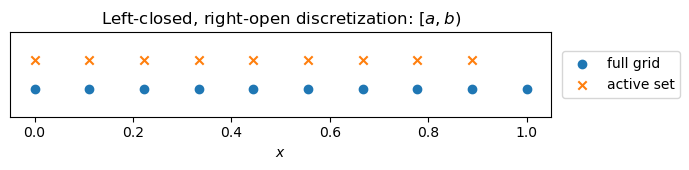

In [26]:
# left-closed, right-open discretization: [a,b)

import numpy as np
import matplotlib.pyplot as plt

# Define the full closed interval [a,b] and the number of grid points.
a = 0.0
b = 1.0
N = 10

# Construct the full coordinate grid.
# This grid includes both endpoints: x[0] = a and x[-1] = b.
x = np.linspace(a, b, N)

# Select the active indices for [a,b).
# This keeps the left endpoint and removes the right endpoint.
active_indices = np.arange(0, N - 1)
x_active = x[active_indices]

# Check that the active subset preserves the grid spacing.
dx = x[1] - x[0]
dx_active = x_active[1] - x_active[0]

assert np.isclose(dx, dx_active)

# Check that the active grid includes a but excludes b.
assert np.isclose(x_active[0], a)
assert not np.isclose(x_active[-1], b)

# Check that the selected active indices are the expected indices.
assert np.array_equal(active_indices, np.arange(0, N - 1))

# Plot the full grid and the active subset.
y = np.ones_like(x)
y_active = np.ones_like(x_active)

fig, ax = plt.subplots(figsize=(7, 1.8))

ax.scatter(
    x,
    y,
    label="full grid",
)

ax.scatter(
    x_active,
    2 * y_active,
    marker="x",
    label="active set",
)

ax.set_ylim(0, 3)
ax.set_yticks([])
ax.set_xlabel("$x$")
ax.set_title("Left-closed, right-open discretization: $[a,b)$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

## Discretization of the Open Interval $(a,b)$

The open interval excludes both endpoints $a$ and $b$:

$$
(a,b)
=
\{x\in\mathbb{R}: a < x < b\}.
$$

In this notebook, the interval $(a,b)$ is represented by selecting the grid points whose indices are

$$
\mathcal{I}_{(a,b)}
=
\{1,2,\ldots,N-2\}.
$$

The corresponding discrete coordinate values are

$$
x_1,x_2,\ldots,x_{N-2}.
$$

Therefore,

$$
x_0 = a,
\qquad
x_{N-1}=b,
\qquad
x_0 \notin \mathbf{x}_{(a,b)},
\qquad
x_{N-1}\notin \mathbf{x}_{(a,b)}.
$$

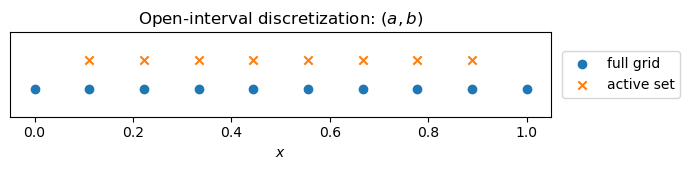

In [ ]:
# open-interval discretization: (a,b)

import numpy as np
import matplotlib.pyplot as plt

# Define the full closed interval [a,b] and the number of grid points.
a = 0.0
b = 1.0
N = 10

# Construct the full coordinate grid.
# This grid includes both endpoints: x[0] = a and x[-1] = b.
x = np.linspace(a, b, N)

# Select the active indices for (a,b).
# This removes both endpoints.
active_indices = np.arange(1, N - 1)
x_active = x[active_indices]

# Check that the active subset preserves the grid spacing.
dx = x[1] - x[0]
dx_active = x_active[1] - x_active[0]

assert np.isclose(dx, dx_active)

# Check that the active grid excludes both endpoints.
assert not np.isclose(x_active[0], a)
assert not np.isclose(x_active[-1], b)

# Check that the selected active indices are the expected indices.
assert np.array_equal(active_indices, np.arange(1, N - 1))

# Plot the full grid and the active subset.
y = np.ones_like(x)
y_active = np.ones_like(x_active)

fig, ax = plt.subplots(figsize=(7, 1.8))

ax.scatter(
    x,
    y,
    label="full grid",
)

ax.scatter(
    x_active,
    2 * y_active,
    marker="x",
    label="active set",
)

ax.set_ylim(0, 3)
ax.set_yticks([])
ax.set_xlabel("$x$")
ax.set_title("Open-interval discretization: $(a,b)$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

N = 400
L = 1.0
a = -L/2
b = L/2
dx = (b-a)/(N+1)
X = a + (np.arange(N) + 1)*dx

assert a not in X
assert b not in X


## Discretization of the Open Interval $(a,b)$

The open interval excludes both endpoints $a$ and $b$:

$$
(a,b)
=
\{x\in\mathbb{R}: a < x < b\}.
$$

In this notebook, the interval $(a,b)$ is represented by selecting the grid points whose indices are

$$
\mathcal{I}_{(a,b)}
=
\{1,2,\ldots,N-2\}.
$$

The corresponding discrete coordinate values are

$$
x_1,x_2,\ldots,x_{N-2}.
$$

Therefore,

$$
x_0 = a,
\qquad
x_{N-1}=b,
\qquad
x_0 \notin \mathbf{x}_{(a,b)},
\qquad
x_{N-1}\notin \mathbf{x}_{(a,b)}.
$$

The NumPy implementation follows in the next cell.

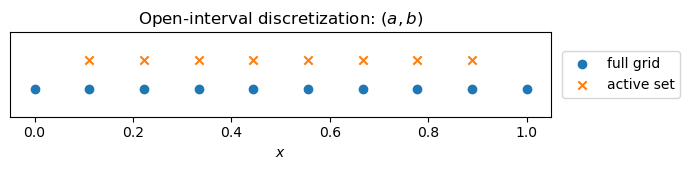

In [28]:
# open-interval discretization: (a,b)

import numpy as np
import matplotlib.pyplot as plt

# Define the full closed interval [a,b] and the number of grid points.
a = 0.0
b = 1.0
N = 10

# Construct the full coordinate grid.
# This grid includes both endpoints: x[0] = a and x[-1] = b.
x = np.linspace(a, b, N)

# Select the active indices for (a,b).
# This removes both endpoints.
active_indices = np.arange(1, N - 1)
x_active = x[active_indices]

# Check that the active subset preserves the grid spacing.
dx = x[1] - x[0]
dx_active = x_active[1] - x_active[0]

assert np.isclose(dx, dx_active)

# Check that the active grid excludes both endpoints.
assert not np.isclose(x_active[0], a)
assert not np.isclose(x_active[-1], b)

# Check that the selected active indices are the expected indices.
assert np.array_equal(active_indices, np.arange(1, N - 1))

# Plot the full grid and the active subset.
y = np.ones_like(x)
y_active = np.ones_like(x_active)

fig, ax = plt.subplots(figsize=(7, 1.8))

ax.scatter(
    x,
    y,
    label="full grid",
)

ax.scatter(
    x_active,
    2 * y_active,
    marker="x",
    label="active set",
)

ax.set_ylim(0, 3)
ax.set_yticks([])
ax.set_xlabel("$x$")
ax.set_title("Open-interval discretization: $(a,b)$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

### Closed interval
$$ x \in [a,b] = X = \{\mathbb{R}:a \leq x \leq b\} $$

$$
  x_i = a + i \Delta x, \quad i=0,1,\ldots,N-1
$$
where
$$
  \Delta x = \frac{b-a}{N-1}
$$

In [11]:
N = 400
L = 1.0
a = -L/2
b = L/2

X = np.linspace(a, b, N, endpoint=True)
dx = X[1] - X[0] 

assert np.isclose(dx, (b-a)/(N-1))
assert a in X
assert b in X


## Grid1D Class Design

In [ ]:
from dataclasses import dataclass
import numpy as np
from enum import Enum, auto



| Active Set Type | Discretized Interval / Set | Active Indices |
|---|---|---|
| `ALL` | $[a,b]$ | $0,1,\ldots,N-1$ |
| `INTERIOR` | $(a,b)$ | $1,2,\ldots,N-2$ |
| `LEFT_CLOSED` | $[a,b)$ | $0,1,\ldots,N-2$ |
| `RIGHT_CLOSED` | $(a,b]$ | $1,2,\ldots,N-1$ |
| `LEFT_BOUNDARY` | $\{a\}$ | $0$ |
| `RIGHT_BOUNDARY` | $\{b\}$ | $N-1$ |
| `BOUNDARY` | $\{a,b\}$ | $0,N-1$ |

In [ ]:
from grid_1d import ActiveSetType1D
from grid_1d import Grid1D

In [4]:
# pytest-style checks for ActiveSetType1D

N = 10

expected_indices = {
    ActiveSetType1D.ALL: np.arange(0, N),
    ActiveSetType1D.INTERIOR: np.arange(1, N - 1),
    ActiveSetType1D.LEFT_CLOSED: np.arange(0, N - 1),
    ActiveSetType1D.RIGHT_CLOSED: np.arange(1, N),
    ActiveSetType1D.LEFT_BOUNDARY: np.array([0]),
    ActiveSetType1D.RIGHT_BOUNDARY: np.array([N - 1]),
    ActiveSetType1D.BOUNDARY: np.array([0, N - 1]),
}

for active_type, expected in expected_indices.items():
    grid = Grid1D(a=0.0, b=1.0, N=N, active_type=active_type)
    assert np.array_equal(grid.active_indices, expected), active_type

print("All ActiveSetType1D checks passed.")

All ActiveSetType1D checks passed.
